In [50]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam



In [51]:
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, width_shift_range=0.2,
                                   height_shift_range=0.2, horizontal_flip=True)
train_generator = train_datagen.flow_from_directory('data/train', target_size=(224, 224),
                                                    batch_size=32, class_mode='categorical')

val_datagen = ImageDataGenerator(rescale=1./255)
val_generator = val_datagen.flow_from_directory('data/validation', target_size=(224, 224),
                                                batch_size=32, class_mode='categorical')


Found 564 images belonging to 6 classes.
Found 127 images belonging to 6 classes.


In [52]:
# Tải mô hình ResNet50 với trọng số đã được huấn luyện trước
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Thêm các lớp fully connected tùy chỉnh vào mô hình
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x) 
predictions = Dense(train_generator.num_classes, activation='softmax')(x)
for layer in base_model.layers:
    layer.trainable = False

In [53]:
model = Model(inputs=base_model.input, outputs=predictions)

In [54]:
# Biên dịch mô hình
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


In [59]:
history= model.fit(train_generator, validation_data=val_generator, epochs=20)

Epoch 1/20
18/18 [==============================] - 53s 3s/step - loss: 1.1415 - accuracy: 0.5567 - val_loss: 0.7184 - val_accuracy: 0.7953
Epoch 2/20
18/18 [==============================] - 49s 3s/step - loss: 1.0693 - accuracy: 0.5798 - val_loss: 0.9420 - val_accuracy: 0.6063
Epoch 3/20
18/18 [==============================] - 49s 3s/step - loss: 1.0135 - accuracy: 0.6312 - val_loss: 0.8648 - val_accuracy: 0.6693
Epoch 4/20
18/18 [==============================] - 46s 3s/step - loss: 1.0573 - accuracy: 0.5798 - val_loss: 0.7127 - val_accuracy: 0.7402
Epoch 5/20
18/18 [==============================] - 46s 3s/step - loss: 1.0237 - accuracy: 0.6046 - val_loss: 0.6867 - val_accuracy: 0.7717
Epoch 6/20
18/18 [==============================] - 46s 3s/step - loss: 1.0643 - accuracy: 0.6046 - val_loss: 0.7788 - val_accuracy: 0.7244
Epoch 7/20
18/18 [==============================] - 46s 3s/step - loss: 1.0789 - accuracy: 0.6046 - val_loss: 0.6977 - val_accuracy: 0.7402
Epoch 8/20
18/18 [==

In [60]:
for layer in base_model.layers[-10:]:  # Unfreeze 10 lớp cuối
    layer.trainable = True

In [61]:
model.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

In [62]:
history= model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10
18/18 [==============================] - 52s 3s/step - loss: 5.4505 - accuracy: 0.3351 - val_loss: 1.8962 - val_accuracy: 0.4803
Epoch 2/10
18/18 [==============================] - 63s 4s/step - loss: 2.2359 - accuracy: 0.5160 - val_loss: 2.2409 - val_accuracy: 0.3150
Epoch 3/10
18/18 [==============================] - 76s 4s/step - loss: 1.6165 - accuracy: 0.5816 - val_loss: 2.9278 - val_accuracy: 0.2992
Epoch 4/10
18/18 [==============================] - 68s 4s/step - loss: 1.2862 - accuracy: 0.6028 - val_loss: 3.2871 - val_accuracy: 0.3071
Epoch 5/10
18/18 [==============================] - 55s 3s/step - loss: 1.1799 - accuracy: 0.6170 - val_loss: 3.1755 - val_accuracy: 0.4173
Epoch 6/10
18/18 [==============================] - 57s 3s/step - loss: 1.0117 - accuracy: 0.6560 - val_loss: 3.5766 - val_accuracy: 0.3543
Epoch 7/10
18/18 [==============================] - 56s 3s/step - loss: 0.9400 - accuracy: 0.6507 - val_loss: 2.9815 - val_accuracy: 0.4331
Epoch 8/10
18/18 [==

In [63]:
import matplotlib.pyplot as plt

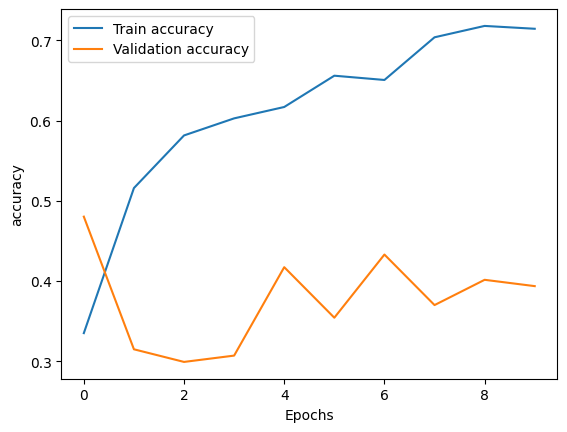

In [64]:
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.legend()
plt.show()